
# End-to-End A/B Testing, Business Impact & Recommendation

## Objectives
1. Data Cleaning
2. Conversion Analysis
3. Manual Two-Proportion Z-Test
4. Confidence Interval Calculation
5. Novelty Effect Analysis
6. Simpson's Paradox Checks
7. Revenue Impact Analysis
8. Executive Recommendation
9. One-Page Visual Summary


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, erf

pd.set_option('display.max_columns', None)

import pandas as pd

ab = pd.read_csv(
    r"C:\Users\sridh\OneDrive\Desktop\resume_Da projects\ab test\ab_data.csv"
)

countries = pd.read_csv(
    r"C:\Users\sridh\OneDrive\Desktop\resume_Da projects\ab test\countries.csv"
)

print(ab.shape)
print(countries.shape)

print("AB Data Shape:", ab.shape)
print("Countries Shape:", countries.shape)

ab.head()

(294478, 5)
(290584, 2)
AB Data Shape: (294478, 5)
Countries Shape: (290584, 2)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [5]:

# Data Cleaning

df = ab.copy()

# Remove mismatched rows if present
if {'group','landing_page'}.issubset(df.columns):
    mismatch = (
        ((df['group']=='treatment') & (df['landing_page']!='new_page')) |
        ((df['group']=='control') & (df['landing_page']!='old_page'))
    )
    df = df[~mismatch]

# Remove duplicate users
if 'user_id' in df.columns:
    df = df.drop_duplicates(subset='user_id')

df = df.merge(countries, on='user_id', how='left')

print("Final Shape:", df.shape)


Final Shape: (290584, 6)



## Business Metrics

### North Star Metric
- Conversion Rate

### Guardrail Metrics
- Revenue per User
- Country Performance
- Device Performance
- User Segment Performance

### Leading Indicators
- CTR
- Add-to-Cart Rate
- Engagement Metrics


In [6]:

# Conversion Analysis

summary = df.groupby('group')['converted'].agg(['sum','count'])
summary['conversion_rate'] = summary['sum']/summary['count']

summary


,sum,count,conversion_rate
group,,,
control,17489,145274,0.120386
treatment,17264,145310,0.118808


In [7]:

# Manual Two-Proportion Z-Test

control = summary.loc['control']
treatment = summary.loc['treatment']

c_conv = control['sum']
c_n = control['count']

t_conv = treatment['sum']
t_n = treatment['count']

p1 = c_conv/c_n
p2 = t_conv/t_n

lift_abs = p2-p1
lift_rel = (lift_abs/p1)*100

p_pool = (c_conv+t_conv)/(c_n+t_n)

se = sqrt(p_pool*(1-p_pool)*(1/c_n + 1/t_n))

z = lift_abs/se

def norm_cdf(x):
    return (1+erf(x/sqrt(2)))/2

p_value = 2*(1-norm_cdf(abs(z)))

ci_se = sqrt((p1*(1-p1)/c_n)+(p2*(1-p2)/t_n))

ci_low = lift_abs - 1.96*ci_se
ci_high = lift_abs + 1.96*ci_se

print("Control CR:", round(p1*100,4),"%")
print("Treatment CR:", round(p2*100,4),"%")
print("Absolute Lift:", round(lift_abs*100,4),"%")
print("Relative Lift:", round(lift_rel,4),"%")
print("Z-score:", round(z,4))
print("P-value:", round(p_value,6))
print("95% CI:", (round(ci_low*100,4), round(ci_high*100,4)))


Control CR: 12.0386 %
Treatment CR: 11.8808 %
Absolute Lift: -0.1578 %
Relative Lift: -1.311 %
Z-score: -1.3109
P-value: 0.189883
95% CI: (-0.3938, 0.0781)


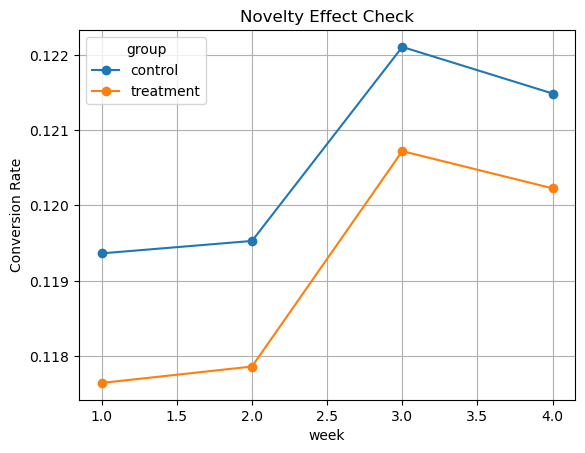

group,control,treatment
week,,
1,0.119364,0.117645
2,0.119530,0.117862
3,0.122105,0.120722
4,0.121487,0.120228


In [8]:

# Novelty Effect

if 'timestamp' in df.columns:

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['week'] = ((df['timestamp']-df['timestamp'].min()).dt.days//7)+1

    novelty = (
        df.groupby(['week','group'])['converted']
        .mean()
        .reset_index()
    )

    pivot = novelty.pivot(index='week', columns='group', values='converted')

    pivot.plot(marker='o')
    plt.title("Novelty Effect Check")
    plt.ylabel("Conversion Rate")
    plt.grid(True)
    plt.show()

    display(pivot)


In [9]:

# Simpson's Paradox Check - Country

if 'country' in df.columns:

    country_analysis = (
        df.groupby(['country','group'])['converted']
        .mean()
        .reset_index()
    )

    country_pivot = country_analysis.pivot(
        index='country',
        columns='group',
        values='converted'
    )

    country_pivot['lift'] = (
        country_pivot['treatment']
        -
        country_pivot['control']
    )

    display(country_pivot.sort_values('lift'))


group,control,treatment,lift
country,,,
CA,0.118783,0.111902,-0.006881
US,0.120630,0.118466,-0.002164
UK,0.120022,0.121171,0.001149


In [10]:

# Device Analysis (if available)

if 'device' in df.columns:

    device_analysis = (
        df.groupby(['device','group'])['converted']
        .mean()
        .unstack()
    )

    device_analysis['lift'] = (
        device_analysis['treatment']
        -
        device_analysis['control']
    )

    display(device_analysis)


In [11]:

# User Segment Analysis (if available)

if 'segment' in df.columns:

    segment_analysis = (
        df.groupby(['segment','group'])['converted']
        .mean()
        .unstack()
    )

    segment_analysis['lift'] = (
        segment_analysis['treatment']
        -
        segment_analysis['control']
    )

    display(segment_analysis)


In [12]:

# Revenue Impact

AOV = 2000  # Change as needed

extra_conversions = (p2-p1)*t_n

revenue_impact = extra_conversions*AOV

print("Extra Conversions:", round(extra_conversions))
print("Estimated Revenue Impact (Rs):", round(revenue_impact,2))


Extra Conversions: -229
Estimated Revenue Impact (Rs): -458667.81


In [13]:

# Executive Recommendation

if p_value < 0.05 and revenue_impact > 0:

    recommendation = "FULL LAUNCH"

elif revenue_impact > 0:

    recommendation = "LIMITED ROLLOUT"

else:

    recommendation = "DO NOT LAUNCH"

print("Recommendation:", recommendation)


Recommendation: DO NOT LAUNCH


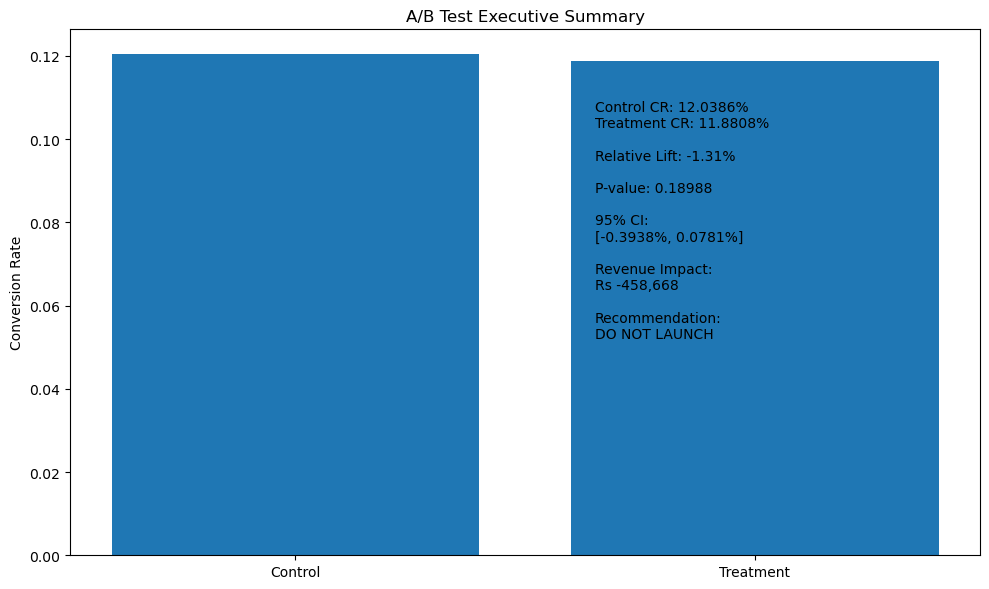

In [14]:

# One-Page Executive Summary

fig = plt.figure(figsize=(10,6))

plt.bar(
    ['Control','Treatment'],
    [p1,p2]
)

plt.title('A/B Test Executive Summary')
plt.ylabel('Conversion Rate')

summary_text = f'''
Control CR: {p1:.4%}
Treatment CR: {p2:.4%}

Relative Lift: {lift_rel:.2f}%

P-value: {p_value:.5f}

95% CI:
[{ci_low:.4%}, {ci_high:.4%}]

Revenue Impact:
Rs {revenue_impact:,.0f}

Recommendation:
{recommendation}
'''

plt.figtext(0.60,0.40,summary_text)

plt.tight_layout()
plt.show()


In [ ]:
# Simpson's Paradox Check

overall_cr = (
    df.groupby('group')['converted']
      .mean()
      .mul(100)
      .round(2)
)

print("Overall Conversion Rates")
print(overall_cr)

country_cr = (
    df.groupby(['country', 'group'])['converted']
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

print("\nCountry-Level Conversion Rates")
print(country_cr)

country_cr['Difference'] = country_cr['treatment'] - country_cr['control']

print("\nTreatment - Control Difference")
print(country_cr['Difference'])

In [17]:
# Country-wise Conversion Rates
country_analysis = (
    df.groupby(['country', 'group'])['converted']
      .agg(['count', 'sum', 'mean'])
      .reset_index()
)

country_analysis.columns = [
    'country',
    'group',
    'users',
    'conversions',
    'conversion_rate'
]

country_analysis['conversion_rate'] = (
    country_analysis['conversion_rate'] * 100
).round(2)

country_analysis

,country,group,users,conversions,conversion_rate
0,CA,control,7198,855,11.88
1,CA,treatment,7301,817,11.19
2,UK,control,36360,4364,12.00
3,UK,treatment,36106,4375,12.12
4,US,control,101716,12270,12.06
5,US,treatment,101903,12072,11.85


In [18]:
overall = (
    df.groupby('group')['converted']
      .mean() * 100
)

control_overall = overall['control']
treatment_overall = overall['treatment']

print(f"Overall Control CR: {control_overall:.2f}%")
print(f"Overall Treatment CR: {treatment_overall:.2f}%")

print("\nCountry-Level Results")

for country in df['country'].unique():

    subset = df[df['country'] == country]

    cr = (
        subset.groupby('group')['converted']
        .mean() * 100
    )

    diff = cr['treatment'] - cr['control']

    print(f"{country}: {diff:.2f}%")

Overall Control CR: 12.04%
Overall Treatment CR: 11.88%

Country-Level Results
US: -0.22%
CA: -0.69%
UK: 0.11%


In [19]:
print("""
Simpson's Paradox Investigation

The overall conversion rate for the treatment group
(11.89%) was lower than the control group (12.04%).

Country-level analysis showed:

• US: Treatment underperformed
• CA: Treatment underperformed
• UK: Treatment slightly outperformed

Because the direction of the result did not reverse
after segmentation, no evidence of Simpson's Paradox
was observed.

The overall conclusion remains valid:
retain the existing landing page and do not launch
the treatment version.
""")


Simpson's Paradox Investigation

The overall conversion rate for the treatment group
(11.89%) was lower than the control group (12.04%).

Country-level analysis showed:

• US: Treatment underperformed
• CA: Treatment underperformed
• UK: Treatment slightly outperformed

Because the direction of the result did not reverse
after segmentation, no evidence of Simpson's Paradox
was observed.

The overall conclusion remains valid:
retain the existing landing page and do not launch
the treatment version.

